1/17
2/17
3/17
4/17
5/17
6/17
7/17
8/17
9/17
10/17
11/17
12/17
13/17
14/17
15/17
16/17
17/17
Transition ALSC = 1 - 1.041 S2/M2
Transition ALSC = 1.029 + 0.918 S2/M2 + -0.519 S2/M2 ^ 2


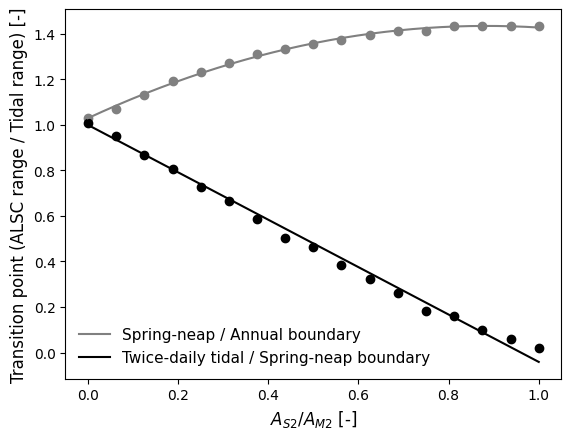

Transition ALSC = 0.002 + 2.205 S2/M2 + -0.786 S2/M2 ^ 2


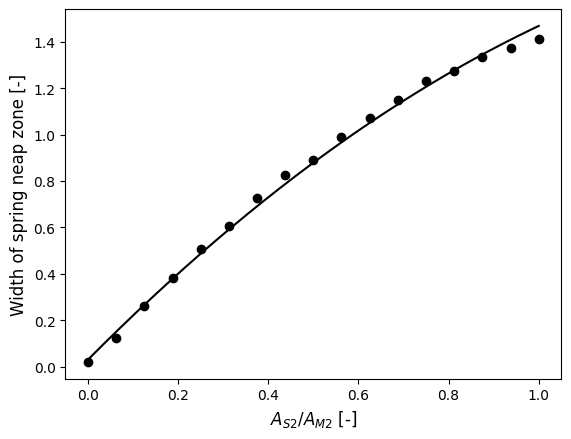

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
# path_root = "D:/backpack_20251001/aslc_intertidal"
path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"

os.chdir(path_root)

import src.functions as f

def plot_figure_s2(path_png):

    def run_simulation_figure_s2(path_bin, amplitude_S2):

        dt = 5/60
        nx, ny = 100, 100
        elevation = np.linspace(-2, 2, nx)[::-1]
        amplitude_annual_cycle = np.linspace(0, 2.0, ny)
        avg_max_inundation_duration = np.array([np.nan]*nx*ny).reshape(nx, ny)
        avg_max_emergent_duration   = np.array([np.nan]*nx*ny).reshape(nx, ny)
        for i in range(ny):
            
            _, waterlevel, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = amplitude_annual_cycle[i], mean_waterlevel = 0., n_years = 2, amplitude_S2 = amplitude_S2, sigma = 0., dt = dt)
            avg_max_inundation_duration[:,i], avg_max_emergent_duration[:,i] = f.find_avg_max_duration(elevation, waterlevel, dt)
            # print(f'{i+1}/{ny}')
            
        # Tile input parameters for saving
        elevation_tiled = np.tile(elevation[:,None], reps = (1, ny))
        amplitude_annual_cycle_tiled = np.tile(amplitude_annual_cycle[None,:], reps = (nx, 1))

        np.save(path_bin, [elevation_tiled, amplitude_annual_cycle_tiled, avg_max_inundation_duration, avg_max_emergent_duration])

    def find_transition_points(path_bin):

        def linear_model(x, a, b):
            return a + x*b
        
        z, aslc, inund_max, emerg_max = np.load(path_bin)
        nz, ntrials = aslc.shape

        tidal, spring_neap, annual = 12.25/24, 29.6, 365.25

        sn_inund_boundary = np.argmin(inund_max < tidal, axis = 0) - 1
        annual_inund_boundary = np.argmin(inund_max < spring_neap, axis = 0) - 1
        annual_emerg_boundary = np.argmax(emerg_max < spring_neap, axis = 0) - 1
        sn_emerg_boundary = np.argmax(emerg_max < tidal, axis = 0) - 1

        x = np.arange(0, ntrials, 1)
        par_inund_sn, _ = curve_fit(linear_model, x, sn_inund_boundary, p0 = (sn_inund_boundary[0],-0.25)) 
        par_emerg_sn, _ = curve_fit(linear_model, x, sn_emerg_boundary, p0 = (sn_emerg_boundary[0],0.25))
        y_inund_sn = linear_model(x, *par_inund_sn)
        y_emerg_sn = linear_model(x, *par_emerg_sn)
        cross_idx_sn = np.argmin(np.abs(y_inund_sn - y_emerg_sn))

        par_inund_annual, _ = curve_fit(linear_model, x, annual_inund_boundary, p0 = (annual_inund_boundary[0],-0.25)) 
        par_emerg_annual, _ = curve_fit(linear_model, x, annual_emerg_boundary, p0 = (annual_emerg_boundary[0],0.25))
        y_inund_annual = linear_model(x, *par_inund_annual)
        y_emerg_annual = linear_model(x, *par_emerg_annual)
        cross_idx_annual = np.argmin(np.abs(y_inund_annual - y_emerg_annual))

        return aslc[0,cross_idx_sn], aslc[0,cross_idx_annual]

    scale = 4
    n = 2**scale + 1
    amplitude_S2 = np.round(np.linspace(0.0, 1, n),3)
    n_trials = amplitude_S2.size
    annual_transition_aslc = np.array([np.nan]*n_trials)
    sn_transition_aslc = np.array([np.nan]*n_trials)
    for i in range(n_trials):
        path_bin = f'./bin/supp_note_1/S2M2={amplitude_S2[i]}.npy'
        if not os.path.exists(path_bin):
            run_simulation_figure_s2(path_bin = path_bin, amplitude_S2 = amplitude_S2[i])
        sn_transition_aslc[i], annual_transition_aslc[i] = find_transition_points(path_bin)
        print(f'{i+1}/{n_trials}')

    # def linear_model(x, b):
    #     return 1 - x*b


    x = np.linspace(amplitude_S2.min(), amplitude_S2.max(), 1000)

    # par0, _ = curve_fit(linear_model, amplitude_S2, sn_transition_aslc, p0 = (1, 1, 1))
    # yp0 = linear_model(x, *par0)
    # print(f'Transition ALSC = {par0[0]:.3f} + {par0[1]:.3f} σ_w + {par0[2]:.3f} σ_w ^ 2')

    def linear_model(x, b):
        return 1 - b*x

    par0, _ = curve_fit(linear_model, amplitude_S2, sn_transition_aslc, p0 = (1))
    yp0 = linear_model(x, *par0)
    print(f'Transition ALSC = 1 - {par0[0]:.3f} S2/M2')

    def linear_model(x, a, b, c):
        return a + b*x + c*x**2

    par1, _ = curve_fit(linear_model, amplitude_S2, annual_transition_aslc, p0 = (1,1,1))
    yp1 = linear_model(x, *par1)
    print(f'Transition ALSC = {par1[0]:.3f} + {par1[1]:.3f} S2/M2 + {par1[2]:.3f} S2/M2 ^ 2')

    plt.plot(x, yp1, c = 'grey', label = 'Spring-neap / Annual boundary')
    plt.scatter(amplitude_S2, annual_transition_aslc, c = 'grey')
    plt.plot(x, yp0, c = 'black', label = 'Twice-daily tidal / Spring-neap boundary')
    plt.scatter(amplitude_S2, sn_transition_aslc, c = 'black')
    plt.xlabel(rf'$A_{{S2}}/A_{{M2}}$ [-]', fontsize = 12)
    plt.ylabel('Transition point (ALSC range / Tidal range) [-]', fontsize = 12)
    plt.legend(frameon = False, fontsize = 11)
    plt.savefig(path_png)
    plt.show()

    sn_zone_width = annual_transition_aslc - sn_transition_aslc
    par2, _ = curve_fit(linear_model, amplitude_S2, sn_zone_width, p0 = (1, 1, 1))
    yp2 = linear_model(x, *par2)

    print(f'Transition ALSC = {par2[0]:.3f} + {par2[1]:.3f} S2/M2 + {par2[2]:.3f} S2/M2 ^ 2')

    plt.plot(x, yp1 - yp0, c = 'black')
    plt.scatter(amplitude_S2, sn_zone_width, c = 'black')
    plt.xlabel(rf'$A_{{S2}}/A_{{M2}}$ [-]', fontsize = 12)
    plt.ylabel('Width of spring neap zone [-]', fontsize = 12)
    # plt.savefig(path_png)
    plt.show()

plot_figure_s2 (path_png = './figures/supp_note_1/figure_s2.png')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


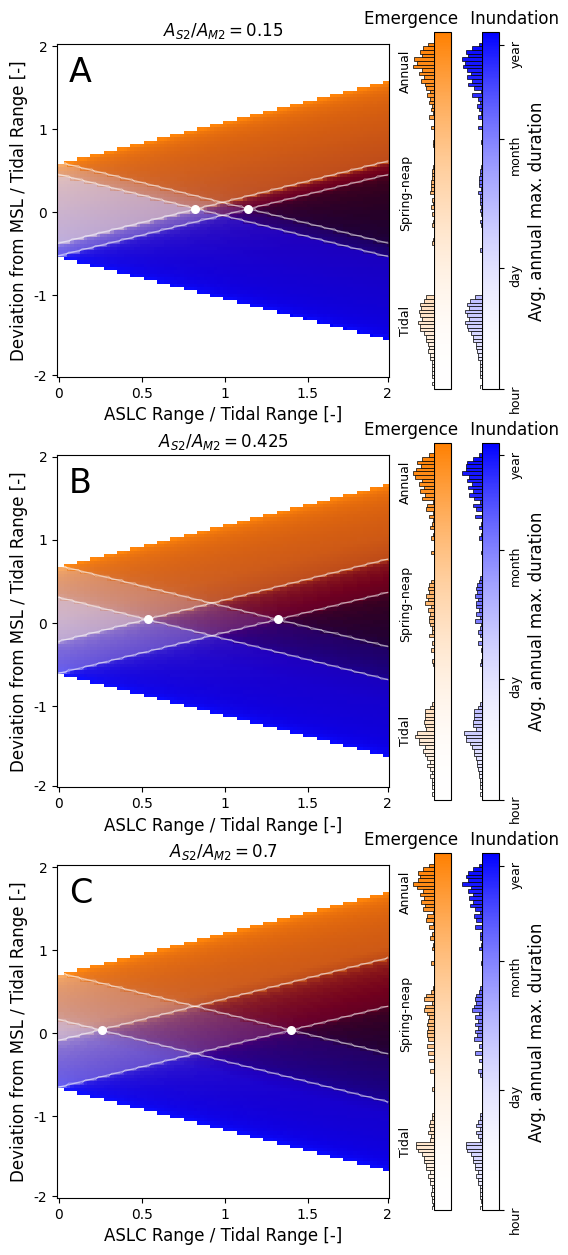

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit

def plot_panel_figure_s1(fig, ax, row, path_bin):
    
    def blend_arrays(array0, array1, xmin, xmax):

        array0, array1 = np.log10(array0), np.log10(array1)
        
        # Normalize arrays between 0 and 1
        a0 = (array0 - xmin) / (xmax - xmin)
        a1 = (array1 - xmin) / (xmax - xmin)
        a0[np.isnan(a0)] = 0
        a1[np.isnan(a1)] = 0 
        a0[a0 > 1] = 1
        a1[a1 > 1] = 1 
        a0[a0 < 0] = 0
        a1[a1 < 0] = 0 

        # Create RGB image: R from array1, B from array0, G optional
        rgb = np.ones((array0.shape[0], array0.shape[1], 3))
        rgb[..., 0] -= a0   # Red channel = array1
        rgb[..., 1] -= (a0 + a1*0.5)   # Green channel = array1
        rgb[..., 2] -= a1   # Blue channel = array0

        return rgb

    def add_zone_boundaries(ax, path_bin):

        def linear_model(x, a, b):
            return a + x*b
        
        z, aslc, inund_max, emerg_max = np.load(path_bin)
        nz, ntrials = aslc.shape

        tidal, spring_neap, annual = 12.25/24, 29.6, 365.25

        sn_inund_boundary = np.argmin(inund_max < tidal, axis = 0) - 1
        annual_inund_boundary = np.argmin(inund_max < spring_neap, axis = 0) - 1
        annual_emerg_boundary = np.argmax(emerg_max < spring_neap, axis = 0) - 1
        sn_emerg_boundary = np.argmax(emerg_max < tidal, axis = 0) - 1

        x = np.arange(0, ntrials, 1)
        par_inund_sn, _ = curve_fit(linear_model, x, sn_inund_boundary, p0 = (sn_inund_boundary[0],-0.25)) 
        par_emerg_sn, _ = curve_fit(linear_model, x, sn_emerg_boundary, p0 = (sn_emerg_boundary[0],0.25))
        y_inund_sn = linear_model(x, *par_inund_sn)
        y_emerg_sn = linear_model(x, *par_emerg_sn)
        cross_idx_sn = np.argmin(np.abs(y_inund_sn - y_emerg_sn))

        par_inund_annual, _ = curve_fit(linear_model, x, annual_inund_boundary, p0 = (annual_inund_boundary[0],-0.25)) 
        par_emerg_annual, _ = curve_fit(linear_model, x, annual_emerg_boundary, p0 = (annual_emerg_boundary[0],0.25))
        y_inund_annual = linear_model(x, *par_inund_annual)
        y_emerg_annual = linear_model(x, *par_emerg_annual)
        cross_idx_annual = np.argmin(np.abs(y_inund_annual - y_emerg_annual))

        ax.plot(x, sn_inund_boundary, color = (1,1,1,0.5), lw = 0.5)
        ax.plot(x, sn_emerg_boundary, color = (1,1,1,0.5), lw = 0.5)
        ax.plot(x, y_inund_sn, color = (1,1,1,0.5), lw = 1)
        ax.plot(x, y_emerg_sn, color = (1,1,1,0.5), lw = 1)
        ax.scatter(cross_idx_sn, nz/2 - 1, s = 30, color = (1,1,1,1))
        
        ax.plot(x, annual_inund_boundary, color = (1,1,1,0.5), lw = 0.5)
        ax.plot(x, annual_emerg_boundary, color = (1,1,1,0.5), lw = 0.5)
        ax.plot(x, y_inund_annual, color = (1,1,1,0.5), lw = 1)
        ax.plot(x, y_emerg_annual, color = (1,1,1,0.5), lw = 1)
        ax.scatter(cross_idx_annual, nz/2 - 1, s = 30, color = (1,1,1,1))

    def add_colorbars(fig, ax, xmin, xmax):
        # Create colorbars
        white  = (1.0, 1.0, 1.0, 0.0)
        blue   = (0.0, 0.0, 1.0, 1.0)
        orange = (1.0, 0.5, 0.0, 1.0)

        cmap0 = LinearSegmentedColormap.from_list("white_to_blue", [white, blue])
        cmap1 = LinearSegmentedColormap.from_list("white_to_orange", [white, orange])

        norm = plt.Normalize(vmin = xmin, vmax = xmax)
        mappable_inund = ScalarMappable(norm=norm, cmap=cmap0)
        mappable_emerg = ScalarMappable(norm=norm, cmap=cmap1)
        
        # Add colorbars using dummy mappables
        cbar0 = fig.colorbar(mappable_inund, ax = ax)
        cbar0.ax.set_ylabel('Avg. annual max. duration', fontsize=12)
        cbar0.ax.set_yticks(ticks = [np.log10(1/24),np.log10(1),np.log10(30),np.log10(365.25)], labels = ['hour','day', 'month', 'year'], fontsize = 9)
        pos = cbar0.ax.get_position()
        new_pos = [pos.x0 - 0.025, pos.y0, pos.width, pos.height]
        cbar0.ax.set_position(new_pos)
        cbar0.ax.tick_params(axis = 'y', labelrotation = 90)
        cbar0.ax.set_title('         Inundation', fontsize=12)

        cbar1 = fig.colorbar(mappable_emerg, ax=ax)
        cbar1.ax.set_yticks(ticks = [])
        cbar1.ax.tick_params(axis = 'y', labelrotation = 90)
        cbar1.ax.set_title('Emergence            ', fontsize=12)
        pos = cbar1.ax.get_position()
        new_pos = [pos.x0 + 0.035, pos.y0, pos.width, pos.height]
        cbar1.ax.set_position(new_pos)

        return cbar0, cbar1

    def add_inund_colorbar_historgram(row, cbar, x, xmin, xmax):
        
        # Create a new Axes next to the colorbar for histogram
        hist_ax0 = fig.add_axes([0.729, 0.6466 - row*0.2683, 0.03, 0.7/3])

        bins = np.linspace(xmin, xmax, 100)
        density, bins = np.histogram(np.log10(x), bins = bins, density = True)
        density = density/density.max()

        for x0, x1, y in zip(bins[:-1], bins[1:], density):
            
            a1 = (x1 - xmin) / (xmax - xmin)
            rect = Rectangle((0, x0), y, x1 - x0, transform=hist_ax0.transData, facecolor = (1 - a1,1 - a1,1,1), edgecolor = (0,0,0,1), lw = 0.5)
            hist_ax0.add_patch(rect)

        hist_ax0.set_ylim(cbar.ax.get_ylim()) 
        hist_ax0.set_xticks([])
        hist_ax0.set_yticks([])
        hist_ax0.set_xlim(0, 1)
        hist_ax0.invert_xaxis()
        for spine in hist_ax0.spines.values():
            spine.set_visible(False)

    def add_emerg_colorbar_historgram(row, cbar, x, xmin, xmax):
        
        # Create a new Axes next to the colorbar for histogram
        hist_ax1 = fig.add_axes([0.657, 0.6466 - row*0.2683, 0.03, 0.7/3])
 
        bins = np.linspace(xmin, xmax, 100)
        density, bins = np.histogram(np.log10(x), bins = bins, density = True)
        density = density/density.max()

        for x0, x1, y in zip(bins[:-1], bins[1:], density):
            
            a1 = (x1 - xmin) / (xmax - xmin)
            rect = Rectangle((0, x0), y, x1 - x0, transform=hist_ax1.transData, facecolor = (1,1 - a1*0.5,1 - a1,1), edgecolor = (0,0,0,1), lw = 0.5)
            hist_ax1.add_patch(rect)

        hist_ax1.text(x = 1.4, y = np.log10(6.125/24), s = 'Tidal', rotation = 90, fontsize = 9, verticalalignment = 'center', horizontalalignment = 'center')
        hist_ax1.text(x = 1.4, y = np.log10(14.8/2), s = 'Spring-neap', rotation = 90, fontsize = 9, verticalalignment = 'center', horizontalalignment = 'center')
        hist_ax1.text(x = 1.4, y = np.log10(365.25/2), s = 'Annual', rotation = 90, fontsize = 9, verticalalignment = 'center', horizontalalignment = 'center')

        hist_ax1.set_ylim(cbar.ax.get_ylim())
        hist_ax1.set_xticks([])
        hist_ax1.set_yticks([])
        hist_ax1.set_xlim(0, 1)
        hist_ax1.invert_xaxis()
        for spine in hist_ax1.spines.values():
            spine.set_visible(False)

    # Load data
    z, aslc, inund_max, emerg_max = np.load(path_bin)
    subset = np.isnan(inund_max) | np.isnan(emerg_max) | (inund_max == 0) | (emerg_max == 0)
    inund_max[subset] = np.nan
    emerg_max[subset] = np.nan

    xmin, xmax = np.log10(1/24), np.log10(365.25*1.4)

    # Plot figure
    rgb = blend_arrays(inund_max, emerg_max, xmin, xmax)
    ax.imshow(rgb, vmin = xmin, vmax = xmax)
    add_zone_boundaries(ax, path_bin)
    cbar0, cbar1 = add_colorbars(fig, ax, xmin, xmax)
    add_inund_colorbar_historgram(row, cbar0, inund_max, xmin, xmax)
    add_emerg_colorbar_historgram(row, cbar1, emerg_max, xmin, xmax)
    ax.set_xlabel('ASLC Range / Tidal Range [-]', fontsize = 12)
    ax.set_ylabel('Deviation from MSL / Tidal Range [-]', fontsize = 12)
    ax.set_xticks(ticks = [0, 25, 50, 75, 99], labels = [0, 0.5, 1, 1.5, 2])
    ax.set_yticks(ticks = [0, 25, 50, 75, 99], labels = [2, 1, 0, -1, -2])

def figure_multipanel_figure_s1(path_png = None):

    rows, cols = 3, 1
    fig = plt.figure(figsize=((6.4 + 0.3)*cols,(4.8 + 0.3)*rows))
    gs = fig.add_gridspec(rows, cols, hspace=.15, wspace=.15) 

    amplitude_S2 = np.array([0.15,0.425,0.7])
    letter = np.array(['A', 'B', 'C'])
    for i in range(amplitude_S2.size):
        ax = fig.add_subplot(gs[i,0])
        plot_panel_figure_s1(fig, ax, row = i, path_bin = f'./bin/supp_note_1/S2M2={amplitude_S2[i]}.npy')
        ax.text(x = 3, y = 3, s = letter[i], horizontalalignment = 'left', verticalalignment = 'top', fontsize = 24)
        ax.set_title(rf'$A_{{S2}}/A_{{M2}} = {amplitude_S2[i]}$')
    if path_png is not None:
        plt.savefig(path_png, dpi = 300, bbox_inches = "tight", pad_inches = 0.2)
    plt.show()

figure_multipanel_figure_s1(path_png = None)
